 INGESTING MULTI-ASSET PORTFOLIO EXECUTIONS (OOS) 
Assets Merged:                 3 Unique Assets (MGC, MNQ, MES)
Total Stitched PnL:            $3,956.00
Portfolio Profit Factor:       1.26
Portfolio Win Rate:            57.58%
Max Portfolio Drawdown:        $-1,546.80
Estimated Sharpe Ratio:        2.68
Total Portfolio Executions:    198 trades


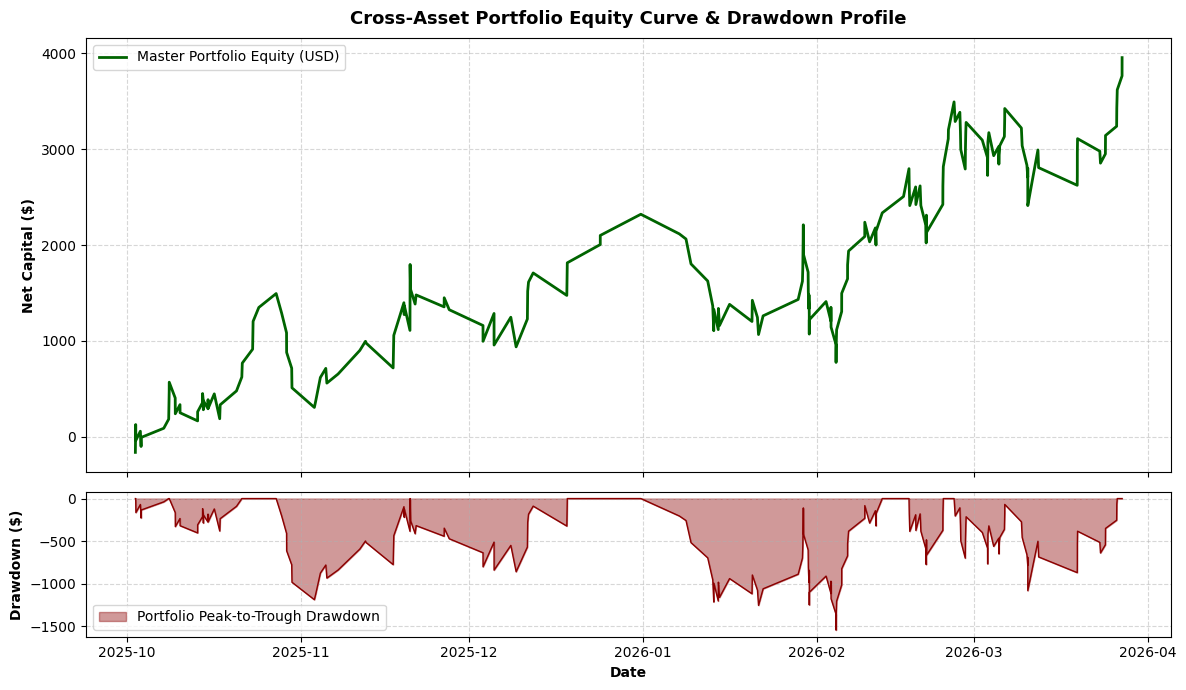

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("=" * 55)
print(" INGESTING MULTI-ASSET PORTFOLIO EXECUTIONS (OOS) ")
print("=" * 55)

csv_files = glob.glob("*.csv")
if not csv_files:
    csv_files = glob.glob("/content/*.csv")

if not csv_files:
    raise FileNotFoundError("No CSV files found. Please upload your trade logs.")

def clean_currency_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    cleaned = (series.astype(str).str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False).str.replace('(', '-', regex=False)
               .str.replace(')', '', regex=False).str.strip())
    return pd.to_numeric(cleaned, errors='coerce').fillna(0.0)

processed_dfs = []
unidentified_files = []

for file in csv_files:
    temp_df = pd.read_csv(file)
    temp_df.columns = [c.strip() for c in temp_df.columns]

    date_candidates = ['Exit time', 'Exit Time', 'Entry time', 'Entry Time', 'Date', 'Time', 'Timestamp']
    pnl_candidates = ['Profit', 'Net profit', 'Net Profit', 'Profit ($)', 'Net_PnL', 'PnL', 'Cum. profit']

    matched_date = next((col for col in date_candidates if col in temp_df.columns), None)
    matched_pnl = next((col for col in pnl_candidates if col in temp_df.columns), None)

    if matched_date and matched_pnl:
        temp_df['Date'] = pd.to_datetime(temp_df[matched_date], errors='coerce', dayfirst=True)
        temp_df['Net_PnL'] = clean_currency_series(temp_df[matched_pnl])

        # THE ULTIMATE FIX: Read the actual instrument directly from NinjaTrader's data column
        instrument_col = next((col for col in temp_df.columns if 'Instrument' in col), None)

        if instrument_col:
            # Extracts just the ticker (e.g., "MNQ" from "MNQ 09-26")
            temp_df['Asset'] = temp_df[instrument_col].astype(str).str.split(' ').str[0].str.upper()
        else:
            # Fallback to filename if the Instrument column was somehow deleted
            file_upper = os.path.basename(file).upper()
            if 'MNQ' in file_upper or 'NQ' in file_upper:
                temp_df['Asset'] = 'MNQ'
            elif 'MES' in file_upper or 'ES' in file_upper:
                temp_df['Asset'] = 'MES'
            elif 'MGC' in file_upper or 'GC' in file_upper:
                temp_df['Asset'] = 'MGC'
            else:
                temp_df['Asset'] = 'Unknown'
                unidentified_files.append(os.path.basename(file))

        processed_dfs.append(temp_df[['Date', 'Net_PnL', 'Asset']].dropna(subset=['Date']))

if not processed_dfs:
    raise ValueError("Valid NinjaTrader columns not found in uploaded CSVs.")

portfolio_df = pd.concat(processed_dfs, ignore_index=True)
portfolio_df = portfolio_df.sort_values('Date').reset_index(drop=True)

portfolio_df['Cumulative_Equity'] = portfolio_df['Net_PnL'].cumsum()
portfolio_df['Peak'] = portfolio_df['Cumulative_Equity'].cummax()
portfolio_df['Drawdown'] = portfolio_df['Cumulative_Equity'] - portfolio_df['Peak']
max_drawdown = portfolio_df['Drawdown'].min()

total_profit = portfolio_df['Net_PnL'].sum()
winning_trades = portfolio_df[portfolio_df['Net_PnL'] > 0]['Net_PnL']
losing_trades = portfolio_df[portfolio_df['Net_PnL'] < 0]['Net_PnL']

num_trades = len(portfolio_df)
win_rate = (len(winning_trades) / num_trades) * 100 if num_trades > 0 else 0.0
pf = winning_trades.sum() / abs(losing_trades.sum()) if losing_trades.sum() != 0 else np.inf

daily_returns = portfolio_df.groupby(portfolio_df['Date'].dt.date)['Net_PnL'].sum()
sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if len(daily_returns) > 1 and daily_returns.std() != 0 else 0.0

unique_assets = portfolio_df['Asset'].unique()

print(f"Assets Merged:                 {len(unique_assets)} Unique Assets ({', '.join(unique_assets)})")
print(f"Total Stitched PnL:            ${total_profit:,.2f}")
print(f"Portfolio Profit Factor:       {pf:.2f}")
print(f"Portfolio Win Rate:            {win_rate:.2f}%")
print(f"Max Portfolio Drawdown:        ${max_drawdown:,.2f}")
print(f"Estimated Sharpe Ratio:        {sharpe_ratio:.2f}")
print(f"Total Portfolio Executions:    {num_trades} trades")
print("=" * 55)
if unidentified_files:
    print(f"WARNING: Could not identify asset for {len(unidentified_files)} file(s). Labeled as 'Unknown'.")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(portfolio_df['Date'], portfolio_df['Cumulative_Equity'], label='Master Portfolio Equity (USD)', color='#006400', linewidth=2)
ax1.set_title('Cross-Asset Portfolio Equity Curve & Drawdown Profile', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Net Capital ($)', fontsize=10, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

ax2.fill_between(portfolio_df['Date'], portfolio_df['Drawdown'], 0, color='#8B0000', alpha=0.4, label='Portfolio Peak-to-Trough Drawdown')
ax2.plot(portfolio_df['Date'], portfolio_df['Drawdown'], color='#8B0000', linewidth=1)
ax2.set_ylabel('Drawdown ($)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Date', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()